Olá, André

Meu nome é Ramon. Ao ao longo do texto farei algumas observações sobre melhorias no código. Nas partes em que não houver comentários, está tudo certo, ok? Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser consertado, caso contrário seu projeto **não** será aceito.
</div>

Você pode me responder usando isso:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

###

<div class="alert alert-block alert-success">
<b>Comentário Geral do Revisor</b> <a class="tocSkip"></a>

Obrigado por enviar seu projeto. 
    
Parabéns, você fez um bom trabalho.

Como pontos fortes do projeto, destaco:
- Código simples e eficiente (sem loop desnecessário)
- Uso adequado dos recursos da lição

    
<span class="text-danger">Porém, há espaço para melhorias: </span>
 * <span class="text-danger"> apresentar conclusões. um notebook é usado para documentar os passos e apresntar análises/conclusões. </span>


Portanto, sugiro que você corrija os pontos indicados.
    
Se você tiver alguma dúvida sobre de algo que você não tenha entendido, sinta-se à vontade para perguntar ao tutor ou deixar um comentário em **azul** para que, na próxima iteração, eu possa responder.

Conte conosco. Lembre-se de que você pode tirar dúvidas com revisores usando os comentários ou buscar ajuda de um tutor.
Bom trabalho. 


</div>



<div class="alert alert-block alert-success">
<b> Comentário Geral do Revisor Final: </b> <a class="tocSkip"></a>

Tudo certo agora. Desejo sucesso na jornada. Parabéns pelo empenho.
</div>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:

df = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [3]:
df.columns = ['event', 'user_id', 'timestamp', 'exp_id']

In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
df['date'] = df['timestamp'].dt.date

In [5]:
print("Eventos:", len(df))
print("Usuários:", df['user_id'].nunique())
print("Média de eventos por usuário:", df.groupby('user_id')['event'].count().mean())

Eventos: 244126
Usuários: 7551
Média de eventos por usuário: 32.33028737915508


In [6]:
print(df['timestamp'].min())
print(df['timestamp'].max())

2019-07-25 04:43:36
2019-08-07 21:15:17


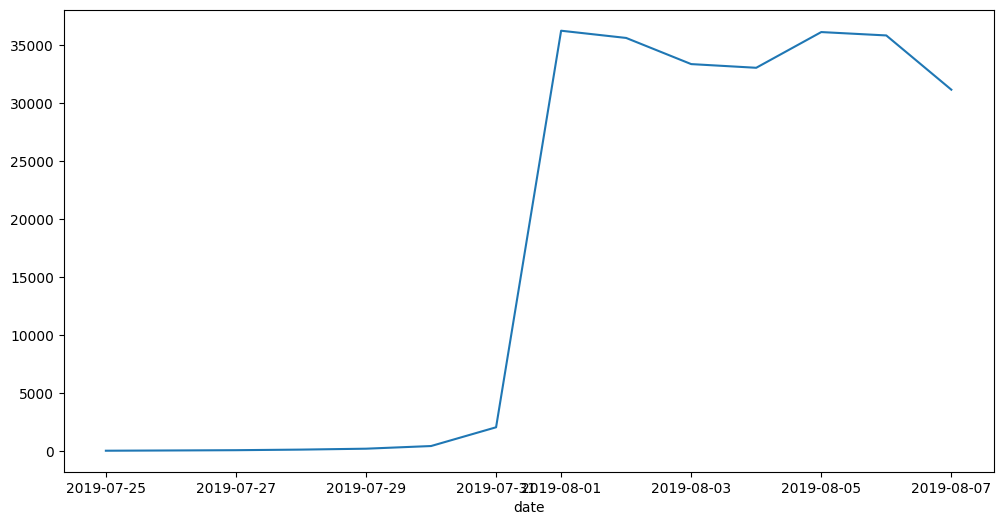

In [7]:
df.groupby('date')['event'].count().plot(figsize=(12,6))
plt.show()

In [8]:
df = df[df['date'] >= pd.to_datetime('2019-08-01').date()]

In [9]:
print("Usuários após corte:", df['user_id'].nunique())
print("Eventos após corte:", len(df))

Usuários após corte: 7534
Eventos após corte: 241298


In [10]:
df['exp_id'].value_counts()

248    84726
246    79425
247    77147
Name: exp_id, dtype: int64

In [11]:
df['event'].value_counts()

MainScreenAppear           117431
OffersScreenAppear          46350
CartScreenAppear            42365
PaymentScreenSuccessful     34113
Tutorial                     1039
Name: event, dtype: int64

In [12]:
users_per_event = df.groupby('event')['user_id'].nunique().sort_values(ascending=False)
users_per_event

event
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Tutorial                    840
Name: user_id, dtype: int64

In [13]:
total_users = df['user_id'].nunique()
(users_per_event / total_users)

event
MainScreenAppear           0.984736
OffersScreenAppear         0.609636
CartScreenAppear           0.495620
PaymentScreenSuccessful    0.469737
Tutorial                   0.111495
Name: user_id, dtype: float64

In [14]:
funnel = [
    'MainScreenAppear',
    'OffersScreenAppear',
    'CartScreenAppear',
    'PaymentScreenSuccessful'
]

In [15]:
funnel_users = []

for step in funnel:
    users = df[df['event'] == step]['user_id'].nunique()
    funnel_users.append(users)

funnel_df = pd.DataFrame({'step': funnel, 'users': funnel_users})
funnel_df

,step,users
0,MainScreenAppear,7419
1,OffersScreenAppear,4593
2,CartScreenAppear,3734
3,PaymentScreenSuccessful,3539


In [16]:
funnel_df['conversion_to_next'] = funnel_df['users'].shift(-1) / funnel_df['users']
funnel_df

,step,users,conversion_to_next
0,MainScreenAppear,7419,0.619086
1,OffersScreenAppear,4593,0.812976
2,CartScreenAppear,3734,0.947777
3,PaymentScreenSuccessful,3539,NaN


In [17]:
funnel_df.iloc[-1]['users'] / funnel_df.iloc[0]['users']

0.47701846610055265

In [18]:
df.groupby('exp_id')['user_id'].nunique()

exp_id
246    2484
247    2513
248    2537
Name: user_id, dtype: int64

In [19]:
from statsmodels.stats.proportion import proportions_ztest

def z_test(group1, group2, event):
    users1 = df[(df['exp_id'] == group1) & (df['event'] == event)]['user_id'].nunique()
    users2 = df[(df['exp_id'] == group2) & (df['event'] == event)]['user_id'].nunique()
    
    n1 = df[df['exp_id'] == group1]['user_id'].nunique()
    n2 = df[df['exp_id'] == group2]['user_id'].nunique()
    
    p1 = users1 / n1
    p2 = users2 / n2
    
    p = (users1 + users2) / (n1 + n2)
    se = np.sqrt(p * (1 - p) * (1/n1 + 1/n2))
    
    z = (p1 - p2) / se
    p_value = (1 - stats.norm.cdf(abs(z))) * 2
    
    return p_value


<div class="alert alert-block alert-warning">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- não está errado, porém é importante usar as bibliotecas pois elas são eficientes e livres de bug.
- oriento usar esta função: https://www.statsmodels.org/dev/generated/statsmodels.stats.proportion.proportions_ztest.html

</div>


In [20]:
for event in funnel:
    print(event, z_test(246, 247, event))

MainScreenAppear 0.7570597232046099
OffersScreenAppear 0.2480954578522181
CartScreenAppear 0.22883372237997213
PaymentScreenSuccessful 0.11456679313141849


In [21]:
for event in funnel:
    print("248 vs 246:", event, z_test(248, 246, event))
    print("248 vs 247:", event, z_test(248, 247, event))

248 vs 246: MainScreenAppear 0.2949721933554552
248 vs 247: MainScreenAppear 0.4587053616621515
248 vs 246: OffersScreenAppear 0.20836205402738917
248 vs 247: OffersScreenAppear 0.9197817830592261
248 vs 246: CartScreenAppear 0.07842923237520116
248 vs 247: CartScreenAppear 0.5786197879539783
248 vs 246: PaymentScreenSuccessful 0.2122553275697796
248 vs 247: PaymentScreenSuccessful 0.7373415053803964


In [22]:
alpha = 0.1
num_tests = 12
corrected_alpha = alpha / num_tests
print("Alpha corrigido:", corrected_alpha)

Alpha corrigido: 0.008333333333333333



<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- quais são as conclusões?

</div>


A análise do funil de eventos mostrou que apenas uma parte dos usuários chega à etapa final de pagamento, com a maior perda ocorrendo antes do início do checkout. Isso indica que, apesar do interesse inicial, muitos usuários desistem nas etapas intermediárias do funil, o que aponta para oportunidades de melhoria nessa fase do aplicativo.

Após a remoção do período inicial com dados incompletos, o conjunto de dados analisado mostrou-se consistente e adequado para o estudo. Os usuários estão corretamente distribuídos entre os três grupos experimentais, garantindo a validade do experimento.

O teste A/A entre os grupos de controle não revelou diferenças estatisticamente significativas, confirmando que a divisão dos usuários foi realizada corretamente e que os resultados são confiáveis. Da mesma forma, a comparação do grupo de teste com os grupos de controle mostrou que a alteração das fontes do aplicativo não teve impacto estatisticamente significativo no comportamento dos usuários nem nas taxas de conversão.

Assim, com base nos dados analisados, conclui-se que o novo design de fontes não prejudica a experiência do usuário, mas também não gera melhorias mensuráveis. As principais oportunidades de aumento de conversão estão relacionadas à otimização das etapas intermediárias do funil, e não à mudança visual testada.

<div class="alert alert-block alert-success">
<b> Comentário do revisor V2: </b> <a class="tocSkip"></a>

Correto
</div>